──────────────────────────────────────────────────────────
  Real Parkinson Tremor Data — DSP Metrics Report
  Dominant Tremor Frequency : 6.53 Hz
──────────────────────────────────────────────────────────
  Notch        | Attenuation:   -36.0 dB | Preservation:  99.5% | EFFECTIVE
  Band-pass    | Attenuation:    -0.1 dB | Preservation:   3.8% | INSUFFICIENT
  Band-stop    | Attenuation:   -45.3 dB | Preservation:  78.3% | EFFECTIVE
──────────────────────────────────────────────────────────


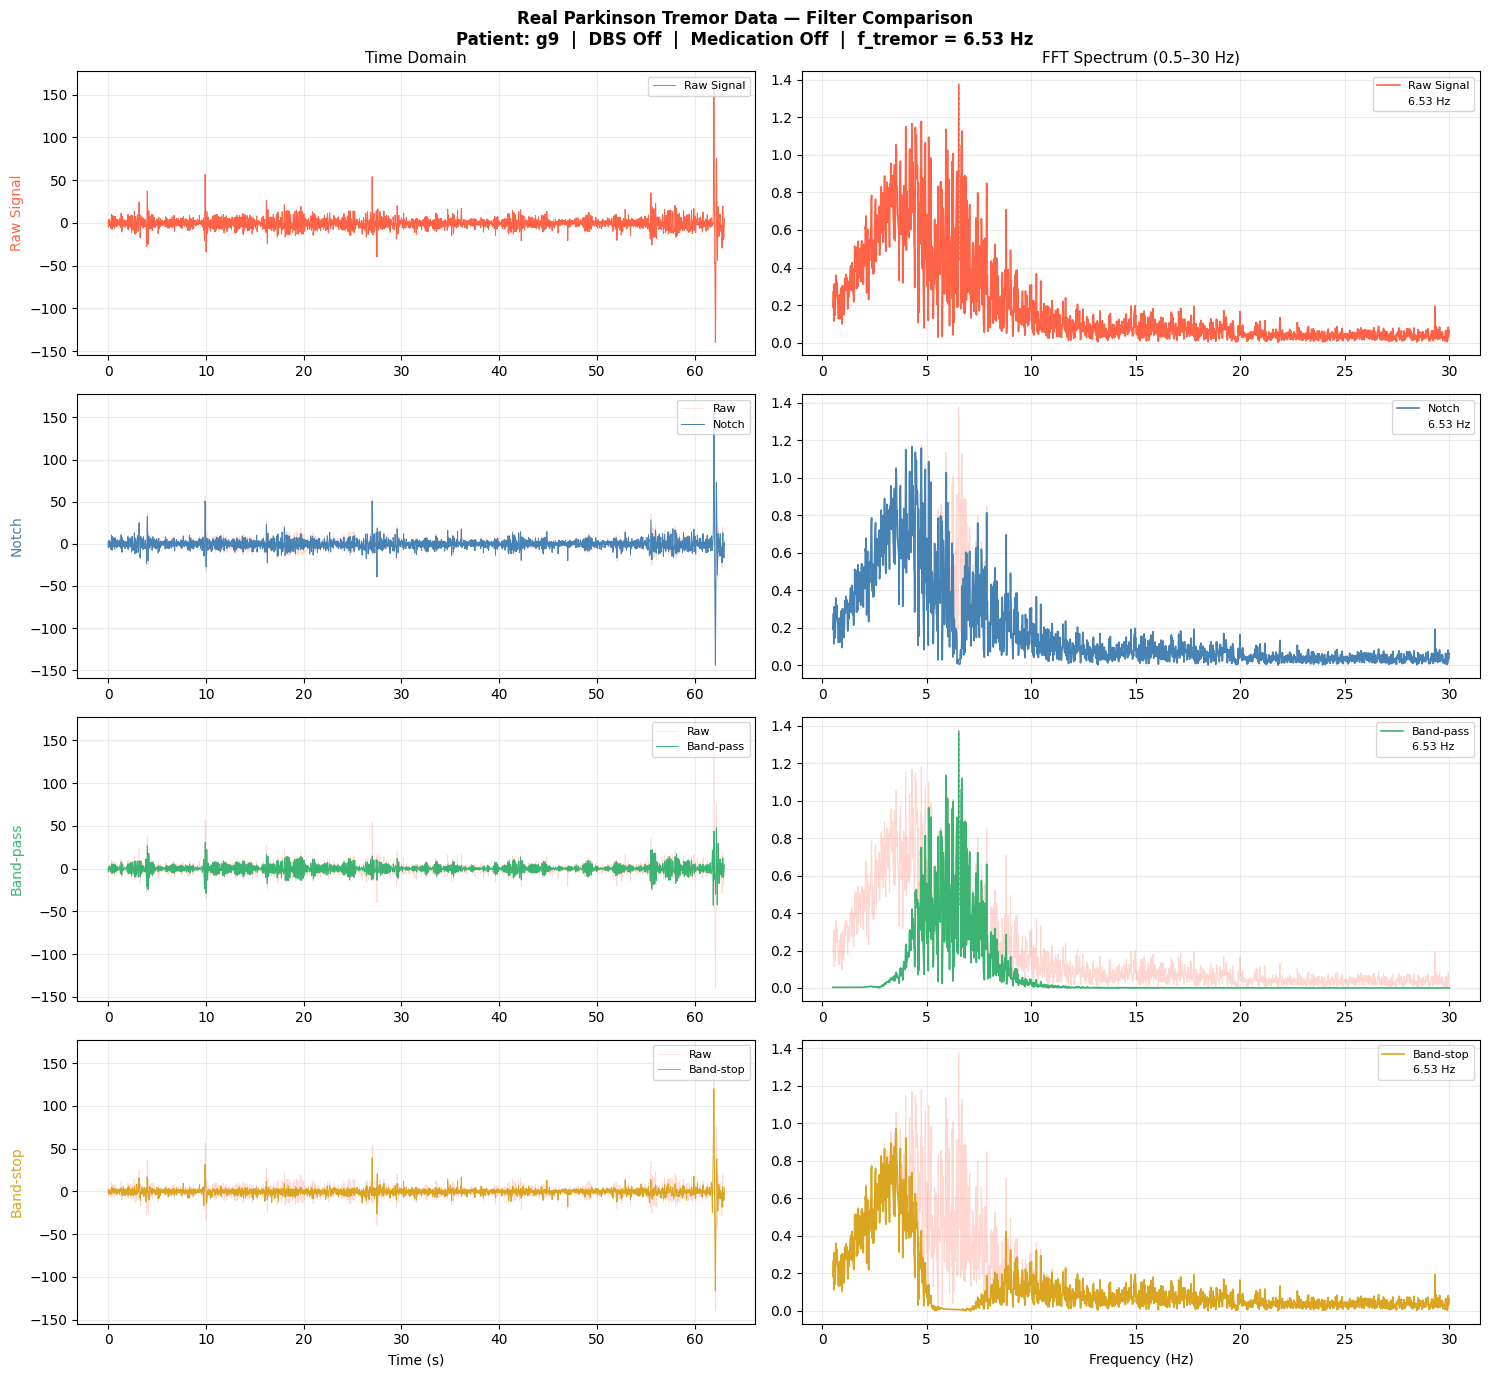


  Saved: real_data_filter_comparison.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# ── Step 1: Load real Parkinson tremor data from PhysioNet ────────
# Patient g9, DBS off, medication off, right hand finger velocity (mm/s)
# Sampling rate: 100 Hz
veri = np.loadtxt("g9r15of.rit")
FS = 100                          # Sampling frequency (Hz)
N = len(veri)                     # Total number of samples
t = np.arange(N) / FS            # Time axis in seconds

# ── Step 2: Remove DC offset ──────────────────────────────────────
# FFT would show a dominant 0 Hz peak if the mean is not removed
# Subtracting the mean centers the signal around zero
veri = veri - np.mean(veri)

# Dominant tremor frequency detected in previous FFT analysis
F_TREMOR = 6.53                   # Hz — Parkinson tremor peak frequency

# ── Step 3: FFT helper function ───────────────────────────────────
# Computes single-sided magnitude spectrum
# Only frequencies between 0.5–30 Hz are returned (skip DC bin)
def tek_fft(x):
    X = fft(x)                                    # Discrete Fourier Transform
    freqs = fftfreq(N, d=1.0/FS)                  # Frequency axis
    mask = (freqs > 0.5) & (freqs <= 30)          # Keep 0.5–30 Hz only
    return freqs[mask], 2 * np.abs(X[mask]) / N   # Normalized magnitude

# ── Step 4: Design three IIR filters ─────────────────────────────

# Filter 1 — Notch filter
# Attenuates a narrow band at exactly F_TREMOR (6.53 Hz)
# Q=15 means bandwidth = F_TREMOR / Q = 0.43 Hz (very selective)
b_notch, a_notch = signal.iirnotch(w0=F_TREMOR, Q=15, fs=FS)

# Filter 2 — Band-pass filter (Butterworth, 2nd order)
# Passes only the tremor band [4.53–8.53 Hz], blocks everything else
# Useful for isolating and analyzing the tremor component
b_bp, a_bp = signal.butter(
    2,
    [F_TREMOR - 2, F_TREMOR + 2],   # Lower and upper cutoff frequencies
    btype="bandpass",
    fs=FS
)

# Filter 3 — Band-stop filter (Butterworth, 2nd order)
# Blocks the tremor band [4.53–8.53 Hz], passes everything else
# Wider rejection than notch — useful when tremor frequency drifts
b_bs, a_bs = signal.butter(
    2,
    [F_TREMOR - 2, F_TREMOR + 2],   # Same band as band-pass
    btype="bandstop",
    fs=FS
)

# ── Step 5: Apply filters using zero-phase filtering ─────────────
# filtfilt applies the filter forward and backward
# Result: zero phase distortion — critical for biomedical signals
notch_out = signal.filtfilt(b_notch, a_notch, veri)
bp_out    = signal.filtfilt(b_bp,    a_bp,    veri)
bs_out    = signal.filtfilt(b_bs,    a_bs,    veri)

# Group all signals for easy iteration
signals = [
    ("Raw Signal",   "tomato",          veri),
    ("Notch",        "steelblue",       notch_out),
    ("Band-pass",    "mediumseagreen",  bp_out),
    ("Band-stop",    "goldenrod",       bs_out),
]

# ── Step 6: Compute DSP performance metrics ───────────────────────
# Attenuation: how much the filter reduces the tremor peak (dB)
# Preservation: how much out-of-band signal energy is retained (%)
print("─" * 58)
print(f"  Real Parkinson Tremor Data — DSP Metrics Report")
print(f"  Dominant Tremor Frequency : {F_TREMOR} Hz")
print("─" * 58)

freqs_r, mag_r = tek_fft(veri)

# Index of the tremor frequency bin in the FFT array
peak_bin = np.argmin(np.abs(freqs_r - F_TREMOR))

for name, color, s in signals[1:]:   # Skip raw signal
    freqs_f, mag_f = tek_fft(s)

    # Attenuation at tremor frequency (dB)
    # Negative value = suppression. Target: below -20 dB
    att = 20 * np.log10(
        (mag_f[peak_bin] + 1e-12) / (mag_r[peak_bin] + 1e-12)
    )

    # Signal preservation — out-of-band energy ratio (%)
    # Frequencies more than 2 Hz away from tremor peak
    band_mask = np.abs(freqs_r - F_TREMOR) > 2.0
    pres = min(100, np.sum(mag_f[band_mask]**2) /
               (np.sum(mag_r[band_mask]**2) + 1e-12) * 100)

    status = "EFFECTIVE" if att < -20 else "INSUFFICIENT"
    print(f"  {name:<12} | Attenuation: {att:>7.1f} dB | "
          f"Preservation: {pres:>5.1f}% | {status}")

print("─" * 58)

# ── Step 7: Visualization — 4 rows x 2 columns ───────────────────
# Left column  : time domain
# Right column : FFT magnitude spectrum
fig, axes = plt.subplots(4, 2, figsize=(15, 14))
fig.suptitle(
    f"Real Parkinson Tremor Data — Filter Comparison\n"
    f"Patient: g9  |  DBS Off  |  Medication Off  |"
    f"  f_tremor = {F_TREMOR} Hz",
    fontsize=12, fontweight="bold"
)

for i, (name, color, s) in enumerate(signals):
    freqs_s, mag_s = tek_fft(s)

    # ── Left panel: time domain ───────────────────────────────────
    ax_t = axes[i, 0]
    if i > 0:
        # Show raw signal in background for comparison
        ax_t.plot(t, veri, color="tomato", lw=0.5, alpha=0.25, label="Raw")
    ax_t.plot(t, s, color=color, lw=0.7, label=name)
    ax_t.set_ylabel(name, fontsize=10, color=color)
    ax_t.grid(True, alpha=0.25)
    ax_t.legend(fontsize=8, loc="upper right")
    if i == 0:
        ax_t.set_title("Time Domain", fontsize=11)
    if i == 3:
        ax_t.set_xlabel("Time (s)")

    # ── Right panel: FFT spectrum ─────────────────────────────────
    ax_f = axes[i, 1]
    if i > 0:
        # Show raw spectrum in background for comparison
        ax_f.plot(freqs_r, mag_r, color="tomato", lw=0.8, alpha=0.25)
    ax_f.plot(freqs_s, mag_s, color=color, lw=1.2, label=name)

    # Vertical marker at tremor frequency
    ax_f.axvline(F_TREMOR, color="white", lw=0.7,
                 ls="--", alpha=0.4, label=f"{F_TREMOR} Hz")
    ax_f.grid(True, alpha=0.25)
    ax_f.legend(fontsize=8, loc="upper right")
    if i == 0:
        ax_f.set_title("FFT Spectrum (0.5–30 Hz)", fontsize=11)
    if i == 3:
        ax_f.set_xlabel("Frequency (Hz)")

# ── Step 8: Save and display ──────────────────────────────────────
plt.tight_layout()
plt.savefig("real_data_filter_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Saved: real_data_filter_comparison.png")
